# Correct dataset formatting

### Sliding window dataset: (UE × time window → future event)

In [ ]:
# Core
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import accuracy_score, recall_score, classification_report, confusion_matrix

In [ ]:
# Replace with your path
df = pd.read_csv("../../dataset/raw/handover_dataset.csv")

df.head()

,timestamp,ue_id,scenario_id,rsrp,sinr,rsrq,cqi,position_x,position_y,altitude,...,hysteresis,time_to_trigger,measurement_interval,zone_density,rlf_flag,drone_strategy,nearest_drone_lat,nearest_drone_lon,nearest_drone_alt,nearest_drone_speed_ms
0,2024-09-01 00:00:00,UE_001,1,-75.10,4.46,-19.5,7,3595.23,1594.38,1.5,...,3.0,256,0.2,dense_urban,0,NaN,0.0,0.0,0.0,0.0
1,2024-09-01 00:00:00,UE_002,1,-118.92,-1.84,-19.5,3,2915.23,5089.24,1.5,...,3.0,256,0.2,dense_urban,0,NaN,0.0,0.0,0.0,0.0
2,2024-09-01 00:00:00,UE_003,1,-104.06,1.12,-19.5,5,3867.22,3398.50,1.5,...,3.0,256,0.2,dense_urban,0,NaN,0.0,0.0,0.0,0.0
3,2024-09-01 00:00:00,UE_004,1,-98.89,-2.28,-19.5,3,4329.51,4066.80,1.5,...,3.0,256,0.2,dense_urban,0,NaN,0.0,0.0,0.0,0.0
4,2024-09-01 00:00:00,UE_005,1,-53.79,17.01,-19.5,13,3705.00,3397.11,1.5,...,3.0,256,0.2,dense_urban,0,NaN,0.0,0.0,0.0,0.0


## Remove listed features and split them to individual features


In [ ]:
def parse_array(x):
    return [float(i) for i in x.strip("[]").replace(",", ";").split(";")]

def top_k(arr, k=3):
    arr = sorted(arr, reverse=True)
    return arr[:k] + [0] * (k - len(arr))

In [ ]:
topk_features = {
    "nb_rsrps": "rsrp",
    "nb_sinrs": "sinr",
    "nb_loads": "load",
    "nb_tp_ests": "tp",
    "nb_scores": "score"
}

In [ ]:
K = 3  # number of top neighbors

for col, prefix in topk_features.items():
    df[[f"{prefix}_{i+1}" for i in range(K)]] = df[col].apply(
        lambda x: pd.Series(top_k(parse_array(x), K))
    )

In [ ]:
def top_k_low(arr, k=3):
    arr = sorted(arr)  # ascending
    return arr[:k] + [0] * (k - len(arr))

In [ ]:
low_features = {
    "nb_dists_m": "dist",
    "nb_path_losses_db": "path_loss"
}

for col, prefix in low_features.items():
    df[[f"{prefix}_{i+1}" for i in range(K)]] = df[col].apply(
        lambda x: pd.Series(top_k_low(parse_array(x), K))
    )

KeyboardInterrupt: 

### change

### Step 1 — define time ordering

In [ ]:
df = df.sort_values(["timestamp", "ue_id"])

### Step 2 — create a global time index

In [ ]:
df["time_id"] = df["timestamp"].rank(method="dense").astype(int)

### 🧠 Step 3 — core idea: sliding window per UE

We build:

- X(t) = past W steps of UE state
- y(t) = event in [t, t+5s]

Example window design

Assume:

- sampling = 200ms
- 5s horizon = 25 steps

So:

- input window = last 10 steps (2s history)
- prediction = next 25 steps (handover event)

### 🔥 Step 4 — build sequences per UE

In [ ]:
W_IN = 10     # past context
W_OUT = 25    # future horizon (~5s)

### Step 5 — build windowed dataset
Core logic:

For each UE:

- X[t] = sequence[t-W_IN : t]
- y[t] = label[t : t+W_OUT]

#### future label per UE

You must compute:

most important HO event in next 5s

Correct rule:

We use priority (telecom logic):

6 > 3 > 5 > 1 > 0

#### label construction
Logic:

For each time t:

- look at handover_class[t+1 : t+H]
- take highest priority event

In [ ]:
import numpy as np

priority = {
    0: 0,  # no HO
    1: 1,  # intra_freq
    3: 2,  # inter_rat
    5: 3,  # drone_to_macro
    6: 4   # emergency
}

def build_label(df, H=W_OUT):
    df = df.sort_values(["ue_id", "timestamp"]).copy()
    df["y"] = 0

    for ue, g in df.groupby("ue_id"):
        idx = g.index.to_numpy()
        events = g["handover_class"].values

        for i in range(len(g)):
            future = events[i+1:i+H]

            if len(future) == 0:
                continue

            best_event = 0
            best_score = -1

            for e in future:
                if priority.get(e, 0) > best_score:
                    best_score = priority[e]
                    best_event = e

            df.loc[idx[i], "y"] = best_event

    return df

## 🚀 2) Clean feature pipeline

### STEP 0 — basic safety cleanup

In [ ]:
df = df.sort_values(["ue_id", "timestamp"]).copy()

df.replace([np.inf, -np.inf], np.nan, inplace=True)

### STEP 1 — CORE RADIO FEATURES

In [ ]:
base_features = [
    "rsrp",
    "sinr",
    "rsrq",
    "cqi",
    "speed",
    "direction",
    "cell_load",
    "interference_level",
    "latency",
    "throughput",
    "packet_loss",
    "jitter"
]

### STEP 2 — UE-LEVEL TEMPORAL FEATURES

#### 2.1 First-order dynamics (velocity of signal change)

In [ ]:
df["rsrp_delta"] = df.groupby("ue_id")["rsrp"].diff().fillna(0)
df["sinr_delta"] = df.groupby("ue_id")["sinr"].diff().fillna(0)
df["rsrq_delta"] = df.groupby("ue_id")["rsrq"].diff().fillna(0)

df["speed_delta"] = df.groupby("ue_id")["speed"].diff().fillna(0)

#### 2.2 Acceleration (VERY useful for HO prediction)

In [ ]:
df["rsrp_acc"] = df.groupby("ue_id")["rsrp_delta"].diff().fillna(0)
df["sinr_acc"] = df.groupby("ue_id")["sinr_delta"].diff().fillna(0)

#### 2.3 Rolling statistics (trend detection)

Use small window (5–10 steps):

In [ ]:
W_ROLL = 5

In [ ]:
df["rsrp_mean"] = df.groupby("ue_id")["rsrp"].rolling(W_ROLL).mean().reset_index(0, drop=True)
df["rsrp_std"] = df.groupby("ue_id")["rsrp"].rolling(W_ROLL).std().reset_index(0, drop=True)

df["sinr_mean"] = df.groupby("ue_id")["sinr"].rolling(W_ROLL).mean().reset_index(0, drop=True)
df["sinr_std"] = df.groupby("ue_id")["sinr"].rolling(W_ROLL).std().reset_index(0, drop=True)

Fill rolling NaNs

In [ ]:
df[["rsrp_mean","rsrp_std","sinr_mean","sinr_std"]] = \
df[["rsrp_mean","rsrp_std","sinr_mean","sinr_std"]].fillna(0)

### STEP 3 — HO STABILITY FEATURES
These capture instability before HO happens.

#### 3.1 Signal degradation indicator

In [ ]:
df["rsrp_drop"] = df["rsrp"] - df["rsrp_mean"]
df["sinr_drop"] = df["sinr"] - df["sinr_mean"]

#### 3.2 Volatility score

In [ ]:
df["radio_volatility"] = df["rsrp_std"] + df["sinr_std"]

#### 3.3 Mobility pressure

In [ ]:
df["mobility_pressure"] = df["speed"] * df["radio_volatility"]

### STEP 4 — CELL COMPETITION FEATURES
This is what usually makes HO prediction work well.

#### 4.1 Best vs second best cell gap

In [ ]:
df["rsrp_gap_1_2"] = df["rsrp_1"] - df["rsrp_2"]
df["sinr_gap_1_2"] = df["sinr_1"] - df["sinr_2"]

#### 4.2 Serving vs target gap

In [ ]:
df["rsrp_serving_gap"] = df["rsrp_1"] - df["rsrp"]
df["sinr_serving_gap"] = df["sinr_1"] - df["sinr"]

#### 4.3 Cell dominance ratio

In [ ]:
df["dist_ratio"] = df["dist_1"] / (df["dist_2"] + 1e-6)

### STEP 5 — A3 / HO TRIGGER FEATURES
This directly encodes 3GPP logic.

In [ ]:
df["A3_condition"] = (df["rsrp_1"] - df["rsrp"]) - df["hysteresis"]
df["ttt_effect"] = df["A3_condition"] * df["time_to_trigger"]

### STEP 6 — SPATIAL / MOBILITY FEATURES

In [ ]:
df["movement_alignment"] = df["speed"] * df["direction"]

### STEP 7 — NEIGHBOR CELL INFORMATION

In [ ]:
def parse_array(col):
    return col.apply(lambda x: np.fromstring(x.strip("[]"), sep=";"))

#### A) Best neighbor cell strength features

From nb_rsrps:

In [ ]:
df["nb_rsrp_max"] = parse_array(df["nb_rsrps"]).apply(np.max)
df["nb_rsrp_mean"] = parse_array(df["nb_rsrps"]).apply(np.mean)
df["nb_rsrp_std"] = parse_array(df["nb_rsrps"]).apply(np.std)

#### B) Best SINR environment features

In [ ]:
df["nb_sinr_max"] = parse_array(df["nb_sinrs"]).apply(np.max)
df["nb_sinr_mean"] = parse_array(df["nb_sinrs"]).apply(np.mean)
df["nb_sinr_std"] = parse_array(df["nb_sinrs"]).apply(np.std)

#### C) Load pressure in neighborhood

In [ ]:
df["nb_load_mean"] = parse_array(df["nb_loads"]).apply(np.mean)
df["nb_load_max"] = parse_array(df["nb_loads"]).apply(np.max)

#### D) Distance structure

In [ ]:
df["nb_dist_min"] = parse_array(df["nb_dists_m"]).apply(np.min)
df["nb_dist_mean"] = parse_array(df["nb_dists_m"]).apply(np.mean)

#### E) Competition strength

In [ ]:
df["nb_rsrp_gap"] = df["nb_rsrp_max"] - df["rsrp"]

#### F) Best neighbor dominance score

In [ ]:
df["nb_score_max"] = parse_array(df["nb_scores"]).apply(np.max)
df["nb_score_mean"] = parse_array(df["nb_scores"]).apply(np.mean)

### STEP 8 — FINAL FEATURE SET

In [ ]:
feature_cols = [
    "rsrp","sinr","rsrq","cqi","speed","direction",

    "rsrp_delta","sinr_delta","rsrq_delta","speed_delta",
    "rsrp_acc","sinr_acc",

    "rsrp_mean","rsrp_std","sinr_mean","sinr_std",

    "rsrp_drop","sinr_drop","radio_volatility","mobility_pressure",

    "rsrp_gap_1_2","sinr_gap_1_2",
    "rsrp_serving_gap","sinr_serving_gap",
    "dist_ratio",

    "nb_rsrp_max","nb_rsrp_mean","nb_rsrp_std",
    "nb_sinr_max","nb_sinr_mean","nb_sinr_std",
    "nb_load_mean","nb_load_max",
    "nb_dist_min","nb_dist_mean",
    "nb_rsrp_gap",
    "nb_score_max","nb_score_mean",

    "A3_condition","ttt_effect",

    "cell_load","interference_level"
]

## build your first LightGBM baseline

### Step 1 - Target

In [ ]:

y = df["handover_class"]

### STEP 2 — Drop unsafe rows

In [ ]:
df = df.dropna(subset=["handover_class"])

### STEP 3 — TIME-BASED SPLIT

In [ ]:
df["timestamp"] = pd.to_datetime(df["timestamp"])

In [ ]:
# sort by time
df = df.sort_values("timestamp")

# split point (e.g. 80% train)
split_time = df["timestamp"].quantile(0.8)

train_df = df[df["timestamp"] <= split_time]
test_df  = df[df["timestamp"] > split_time]

### STEP 4 — Build X / y

In [ ]:
X_train = train_df[feature_cols]
y_train = train_df["handover_class"]

X_test = test_df[feature_cols]
y_test = test_df["handover_class"]

### STEP 5 — Handle remaining NaNs

In [ ]:
X_train = X_train.fillna(0)
X_test  = X_test.fillna(0)

### STEP 6 — Train LightGBM

In [ ]:
from lightgbm import LGBMClassifier

model = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=-1,
    num_leaves=31,
    class_weight="balanced",   # 🔥 IMPORTANT
    random_state=42
)

model.fit(X_train, y_train)

[LightGBM] [Info] Number of positive: 92, number of negative: 38628
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002669 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 8068
[LightGBM] [Info] Number of data points in the train set: 38720, number of used features: 41
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -i

,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.05
,n_estimators,300
,subsample_for_bin,200000
,objective,None
,class_weight,'balanced'
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


### STEP 7 — Evaluation

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      9185
           1       0.93      0.93      0.93        15

    accuracy                           1.00      9200
   macro avg       0.97      0.97      0.97      9200
weighted avg       1.00      1.00      1.00      9200



Confusion matrix

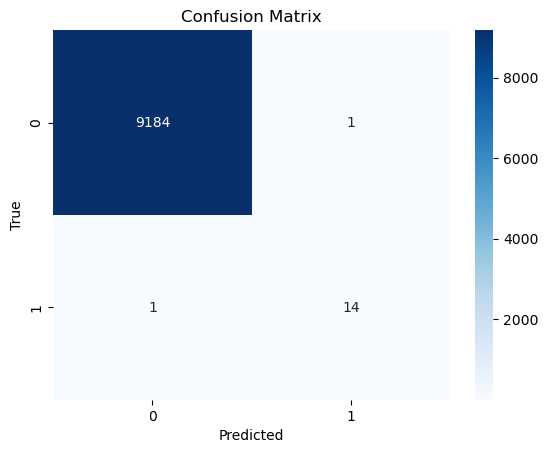

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
import pandas as pd

importance = pd.DataFrame({
    "feature": feature_cols,
    "importance": model.feature_importances_
}).sort_values("importance", ascending=False)

print(importance.head(15))

              feature  importance
11           sinr_acc        1813
24         dist_ratio        1114
14          sinr_mean         728
19  mobility_pressure         685
1                sinr         666
7          sinr_delta         359
8          rsrq_delta         257
40          cell_load         251
34       nb_dist_mean         224
37      nb_score_mean         219
31       nb_load_mean         177
21       sinr_gap_1_2         175
29       nb_sinr_mean         172
23   sinr_serving_gap         171
27        nb_rsrp_std         165
